<a href="https://colab.research.google.com/github/ishikadubey1105/AI-agents-Course/blob/main/AI_AGENTS_FLEXI_CREDIT_COURSE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

!pip install -U "autogen-agentchat" "autogen-ext[openai]" python-dotenv


import os
from google.colab import userdata

os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")



import asyncio
from autogen_agentchat.agents import AssistantAgent
from autogen_ext.models.openai import OpenAIChatCompletionClient

model_client = OpenAIChatCompletionClient(
    model="llama-3.3-70b-versatile",
    base_url="https://api.groq.com/openai/v1",
    api_key=os.environ["GROQ_API_KEY"],
    model_info={
        "vision": False,
        "function_calling": True,
        "json_output": True,
        "family": "unknown",
    },
)

agent = AssistantAgent("assistant", model_client=model_client)

async def main():
    result = await agent.run(task="Say 'Hello World!' and tell me about Autogen")
    print(result.messages[-1].content)

await main()  # Colab supports top-level await

from autogen_agentchat.agents import AssistantAgent

def get_stock_price(ticker: str) -> str:
    """Mock stock price lookup."""
    prices = {"WIPRO": 512.30, "Infosys": 1195.10}
    return f"{ticker}: ${prices.get(ticker.upper(), 'unknown')}"

tool_agent = AssistantAgent(
    "stock_agent",
    model_client=model_client,
    tools=[get_stock_price],
    system_message="You help users look up stock prices using the get_stock_price tool.",
)

async def main():
    result = await tool_agent.run(task="What's the price of WIPRO?")
    print(result.messages[-1].content)

await main()

from autogen_agentchat.agents import AssistantAgent
from autogen_agentchat.conditions import TextMentionTermination
from autogen_agentchat.teams import RoundRobinGroupChat
from autogen_agentchat.ui import Console

researcher = AssistantAgent(
    "researcher",
    model_client=model_client,
    system_message="You gather and summarize key facts on the given topic. Be concise.",
)

writer = AssistantAgent(
    "writer",
    model_client=model_client,
    system_message="You write a polished short paragraph based on the researcher's facts.",
)

critic = AssistantAgent(
    "critic",
    model_client=model_client,
    system_message="You review the writer's paragraph. If it's good, say 'APPROVE'. Otherwise, give one line of feedback.",
)

termination = TextMentionTermination("APPROVE")

team = RoundRobinGroupChat(
    [researcher, writer, critic],
    termination_condition=termination,
    max_turns=9,
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.3/119.3 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.9/101.9 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.4/331.4 kB 12.0 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/autogen_ext/models/openai/_openai_client.py:466: UserWarning: Missing required field 'structured_output' in ModelInfo. This field will be required in a future version of AutoGen.
  validate_model_info(self._model_info)


Hello World. 

Autogen, short for Auto-Generated, refers to the process of automatically generating code, text, or other content using algorithms, models, or tools. In the context of software development, autogen typically involves using templates, scripts, or code generators to produce boilerplate code, such as class definitions, function stubs, or data access layers.

Autogen can be useful for several purposes:

1. **Reducing manual labor**: By automating the generation of repetitive or mundane code, developers can focus on more complex and creative tasks.
2. **Improving consistency**: Autogen can help maintain consistency in coding style, naming conventions, and architecture across a project.
3. **Increasing productivity**: Autogen can speed up the development process by providing a starting point for new features or components.
4. **Enhancing maintainability**: Auto-generated code can be easily updated or regenerated when requirements change, reducing the effort required for mainte

In [2]:
# Step1: Install & Setup

!pip install -U "autogen-agentchat" "autogen-ext[openai]" python-dotenv

import os
from google.colab import userdata
from autogen_ext.models.openai import OpenAIChatCompletionClient

os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")

# Step2: Define the model client (GROQ)

groq_client = OpenAIChatCompletionClient(

    model="llama-3.3-70b-versatile",

    base_url="https://api.groq.com/openai/v1",

    api_key=os.environ["GROQ_API_KEY"],

    model_info={

        "vision": False,

        "function_calling": True,

        "json_output": True,

        "family": "unknown",

    },

)

# OR

# Step2: Define the model client (OpenAI)


openAI_client = OpenAIChatCompletionClient(model="gpt-4o")


# Step3: Design the Agent Team

from autogen_agentchat.agents import AssistantAgent



market_researcher = AssistantAgent(

    "market_researcher",

    model_client=groq_client,

    system_message=(

        "You are a Market Research Analyst. Given a product/brand brief, identify: "

        "target audience segments, competitor positioning, and 2-3 relevant market trends. "

        "Be specific and concise — bullet points, no fluff."

    ),

)



strategist = AssistantAgent(

    "strategist",

    model_client=groq_client,

    system_message=(

        "You are a Marketing Strategist. Using the researcher's findings, propose a "

        "positioning statement, 3 core messaging pillars, and recommended channels "

        "(with rationale). Build directly on what the researcher provided."

    ),

)



copywriter = AssistantAgent(

    "copywriter",

    model_client=groq_client,

    system_message=(

        "You are a Copywriter. Turn the strategist's messaging pillars into: "

        "1 tagline, 1 short social post (under 280 chars), and 1 email subject line. "

        "Match tone to the brand described in the brief."

    ),

)



critic = AssistantAgent(

    "critic",

    model_client=groq_client,

    system_message=(

        "You are a Creative Director reviewing the full package (research, strategy, copy). "

        "Check for consistency, differentiation from competitors, and audience fit. "

        "If it's solid, respond with 'APPROVE'. Otherwise give one specific, actionable "

        "note for whoever should revise (name them)."

    ),

)

# Note: - In step3, replace the groq_client with openAI_client if you want to work with OpenAI Model.



# Step4: Write them into a team

from autogen_agentchat.conditions import TextMentionTermination

from autogen_agentchat.teams import RoundRobinGroupChat

from autogen_agentchat.ui import Console



termination = TextMentionTermination("APPROVE")



marketing_team = RoundRobinGroupChat(

    [market_researcher, strategist, copywriter, critic],

    termination_condition=termination,

    max_turns=12,

)

# Step5: Run it

brief = """

Product: A subscription-based meal-prep kit for busy IT professionals in Pune, India.

Focus: high-protein, quick-cook meals under 20 minutes.

Goal: launch marketing strategy for the first 90 days.

"""



await Console(marketing_team.run_stream(task=brief))

/usr/local/lib/python3.12/dist-packages/autogen_ext/models/openai/_openai_client.py:466: UserWarning: Missing required field 'structured_output' in ModelInfo. This field will be required in a future version of AutoGen.
  validate_model_info(self._model_info)


OpenAIError: Missing credentials. Please pass an `api_key`, `workload_identity`, `admin_api_key`, or set the `OPENAI_API_KEY` or `OPENAI_ADMIN_KEY` environment variable.

In [ ]:
#Install Gradio
!pip install -U gradio

#import gradio
import gradio as gr
print("Gradio imported successfully!")

#Create first python function
def greet(name):
  return "Hello "+name

#Create gradio interface
demo=gr.Interface(
    fn=greet,
    inputs="text",
    outputs="text"
)
demo.launch()

#Give the UI a title
demo=gr.Interface(
    fn=greet,
    inputs=gr.Textbox(
        label="Enter your name here",
        placeholder="Type your name here"
    ),
    outputs=gr.Textbox(
        label="Greetings"
    ),
    title="My First Gradio App",
    description="A simple gradio application"
)
demo.launch()

#Multiple Inputs
def introduce(name, age):
  return f"Hello {name}, you are {age} years old"

#Assign introduce function to gradio
demo=gr.Interface(
    fn=introduce,
    inputs=[
        gr.Textbox(label="Name"),
        gr.Textbox(label="Age")
    ],
    outputs=gr.Textbox(label="Result"),
    title="Introductiomn App"
)
demo.launch()







#Create a Calculator
def calculate(a,b,operation):
  if operation=="Add":
    return a+b
  elif operation=="Substract":
    return a-b
  elif operation=="Multiply":
    return a*b
  elif operation=="Divide":
    return a/b

#Assign calculate function to gradio
demo=gr.Interface(
    fn=calculate,

    inputs=[
        gr.Number(label="Num1"),
        gr.Number(label="Num2"),
        gr.Dropdown(
            choices=["Add","Substract","Multiply","Divide"],
            label="Operation"
        )
    ],

   outputs=gr.Textbox(label="Result"),
    title="Calculator"
)
demo.launch()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 8.5 MB/s eta 0:00:00
  Attempting uninstall: groq
    Found existing installation: groq 1.6.0
    Uninstalling groq-1.6.0:
      Successfully uninstalled groq-1.6.0


Enter your Groq API Key: ··········


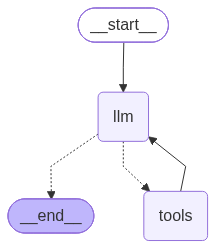

The result of 250 * 4 is 1000.
The weather in Pune is currently sunny with a temperature of 28°C.


In [4]:

!pip install langchain-groq
!pip install langgraph

import os
import getpass

from typing import Literal
from langchain_groq import ChatGroq
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode

from IPython.display import Image, display

!pip install langchain-groq
!pip install langgraph

# ==========================================
# 1. GROQ API KEY
# ==========================================

os.environ["GROQ_API_KEY"] = getpass.getpass(
    "Enter your Groq API Key: "
)

# ==========================================
# 2. GROQ MODEL
# ==========================================

llm = ChatGroq(
    model="qwen/qwen3.6-27b",
    temperature=0
)

# ==========================================
# 3. CUSTOM TOOL
# ==========================================

@tool
def calculator(expression: str) -> str:
    """Calculate a mathematical expression."""

    try:
        result = eval(
            expression,
            {"__builtins__": {}},
            {}
        )

        return str(result)

    except Exception:
        return "Invalid expression."

# ==========================================
# 3. CUSTOM TOOL
# ==========================================
@tool
def get_weather(city: str) -> str:
    """
    Return weather information for a city.
    This is demo data only.
    """

    weather_data = {
        "pune": "Sunny, 28°C",
        "mumbai": "Cloudy, 30°C",
        "delhi": "Clear, 32°C",
        "nagpur": "Sunny, 31°C"
    }

    return weather_data.get(
        city.lower(),
        f"No weather data available for {city}."
    )

# ==========================================
# 4. BIND TOOL TO LLM
# ==========================================

tools = [calculator,get_weather]

llm_with_tools = llm.bind_tools(tools)

tool_node = ToolNode(tools)

# ==========================================
# 5. LLM NODE
# ==========================================

def call_model(state: MessagesState):

    response = llm_with_tools.invoke(
        state["messages"]
    )

    return {
        "messages": [response]
    }

# ==========================================
# 6. CONDITIONAL ROUTING
# ==========================================

def should_continue(
    state: MessagesState
) -> Literal["tools", "__end__"]:

    last_message = state["messages"][-1]

    if last_message.tool_calls:
        return "tools"

    return "__end__"

# ==========================================
# 7. CREATE GRAPH
# ==========================================

builder = StateGraph(MessagesState)

builder.add_node("llm", call_model)

builder.add_node("tools", tool_node)

builder.add_edge(
    START,
    "llm"
)

builder.add_conditional_edges(
    "llm",
    should_continue,
    {
        "tools": "tools",
        "__end__": END
    }
)

builder.add_edge(
    "tools",
    "llm"
)

# ==========================================
# 8. COMPILE
# ==========================================

agent = builder.compile()

# ==========================================
# 9. VISUALIZE GRAPH
# ==========================================

display(
    Image(
        agent.get_graph().draw_mermaid_png()
    )
)

# ==========================================
# 10. Invoke Calculator Agent
# ==========================================

result = agent.invoke({
    "messages": [
        HumanMessage(
            content="Calculate 250 * 4"
        )
    ]
})
print(result["messages"][-1].content)

# ==========================================
# 10. Invoke Weather Agent
# ==========================================

result = agent.invoke({
    "messages": [
        HumanMessage(
            content="What is the weather in Pune?"
        )
    ]
})
print(result["messages"][-1].content)


In [3]:
!pip install -U groq gradio

import os
import getpass

os.environ["GROQ_API_KEY"] = getpass.getpass(
    "Enter your Groq API Key: "
)

print("API key configured successfully!")

from groq import Groq
import gradio as gr
client = Groq( api_key=os.environ["GROQ_API_KEY"] )


response = client.chat.completions.create(
    model="llama-3.3-70b-versatile",
    messages=[
        {
            "role": "user",
            "content": "What is artificial intelligence?"
        }
    ]
)

print(response.choices[0].message.content)


# Now let’s give the AI a role
SYSTEM_PROMPT = """
You are a professional customer support AI assistant.

Your responsibilities:

1. Help customers with orders.
2. Explain return and refund policies.
3. Help with cancellation requests.
4. Help with damaged or defective products.
5. Be polite and professional.
6. Give short and clear answers.
7. If you don't know something, clearly say that you don't know.
8. Never invent order information.
"""


def chatbot(message, history):

    messages = [
        {
            "role": "system",
            "content": SYSTEM_PROMPT
        }
    ]

    # Add previous conversation
    for item in history:

        messages.append({
            "role": item["role"],
            "content": item["content"]
        })

    # Add current user message
    messages.append({
        "role": "user",
        "content": message
    })

    # Call Groq
    response = client.chat.completions.create(
        model="qwen/qwen3.6-27b",
        messages=messages,
        temperature=0.2
    )

    return response.choices[0].message.content

demo = gr.ChatInterface(
    fn=chatbot,

    title="🛒 Customer Support AI",

    description="""
    AI-powered customer support assistant using
    Groq + Llama + Gradio.
    """,

    examples=[
        "What is your return policy?",
        "My order has not arrived. What should I do?",
        "Can I cancel my order?",
        "I received a damaged product. What should I do?",
        "How can I get a refund?"
    ]
)

demo.launch()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.7/30.7 MB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 4.8 MB/s eta 0:00:00
  Attempting uninstall: gradio-client
    Found existing installation: gradio_client 2.5.0
    Uninstalling gradio_client-2.5.0:
      Successfully uninstalled gradio_client-2.5.0
  Attempting uninstall: gradio
    Found existing installation: gradio 6.20.0
    Uninstalling gradio-6.20.0:
      Successfully uninstalled gradio-6.20.0
Enter your Groq API Key: ··········
API key configured successfully!
**Artificial Intelligence (AI) Definition:**

Artificial intelligence (AI) refers to the development of computer systems that can perform tasks that typically require human intelligence, such as:

* Learning
* Problem-solving
* Reasoning
* Perception
* Natural language understanding

**Key Characteristics of AI:**

1. **Machine Learning**: AI systems can le